In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torchvision.transforms as transforms
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from torch.utils.data import Dataset

# Outils de clustering et réduction de dimension
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [67]:
# Chargement du fichier généré au Notebook 2
df_features = pd.read_pickle("features_mri_baseline.pkl")

print(f"Inventaire chargé : {len(df_features)} images.")
print(f"Colonnes disponibles : {df_features.columns.tolist()}")

Inventaire chargé : 1506 images.
Colonnes disponibles : ['path', 'label', 'resnet_final', 'resnet_inter', 'vgg_final', 'vgg_inter']


In [68]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=3.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        img_clahe = self.clahe.apply(img_gray)
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_final)

class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['label'], row['path']

In [69]:
# 1. On prépare les labels réels (pour les 100 images connues)
mask_labeled = df_features['label'] != 'Unknown'
true_labels = df_features[mask_labeled]['label'].map({'cancer': 1, 'normal': 0})

def run_clustering_protocol(layer_column):
    # A. Extraction et Standardisation (Prérequis consigne)
    X = np.stack(df_features[layer_column].values)
    X_scaled = StandardScaler().fit_transform(X)
    
    # B. PCA pour la visualisation
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # C. Clustering K-Means k=2 (Consigne)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    clusters = km.fit_predict(X_scaled)
    
    # D. Calcul ARI (Pour savoir si on est sur le bon chemin)
    score_ari = adjusted_rand_score(true_labels, clusters[mask_labeled])
    
    return X_pca, clusters, score_ari

# Lancement du match
X_pca_final, clus_final, ari_final = run_clustering_protocol('resnet_final')
X_pca_inter, clus_inter, ari_inter = run_clustering_protocol('resnet_inter')

print(f"Score ARI Couche Finale : {ari_final:.4f}")
print(f"Score ARI Couche Intermédiaire : {ari_inter:.4f}")

Score ARI Couche Finale : 0.2642
Score ARI Couche Intermédiaire : 0.4302


In [70]:
# Choix automatique du meilleur modèle
if ari_inter > ari_final:
    winner_name = "Intermédiaire"
    df_features['weak_label'] = clus_inter
    X_pca_winner = X_pca_inter
    ari_winner = ari_inter
else:
    winner_name = "Finale"
    df_features['weak_label'] = clus_final
    X_pca_winner = X_pca_final
    ari_winner = ari_final

print(f"Gagnant : {winner_name} avec un ARI de {ari_winner:.4f}")
print("Labellisation faible terminée. Les images inconnues ont maintenant un label IA dans 'weak_label'.")

Gagnant : Intermédiaire avec un ARI de 0.4302
Labellisation faible terminée. Les images inconnues ont maintenant un label IA dans 'weak_label'.


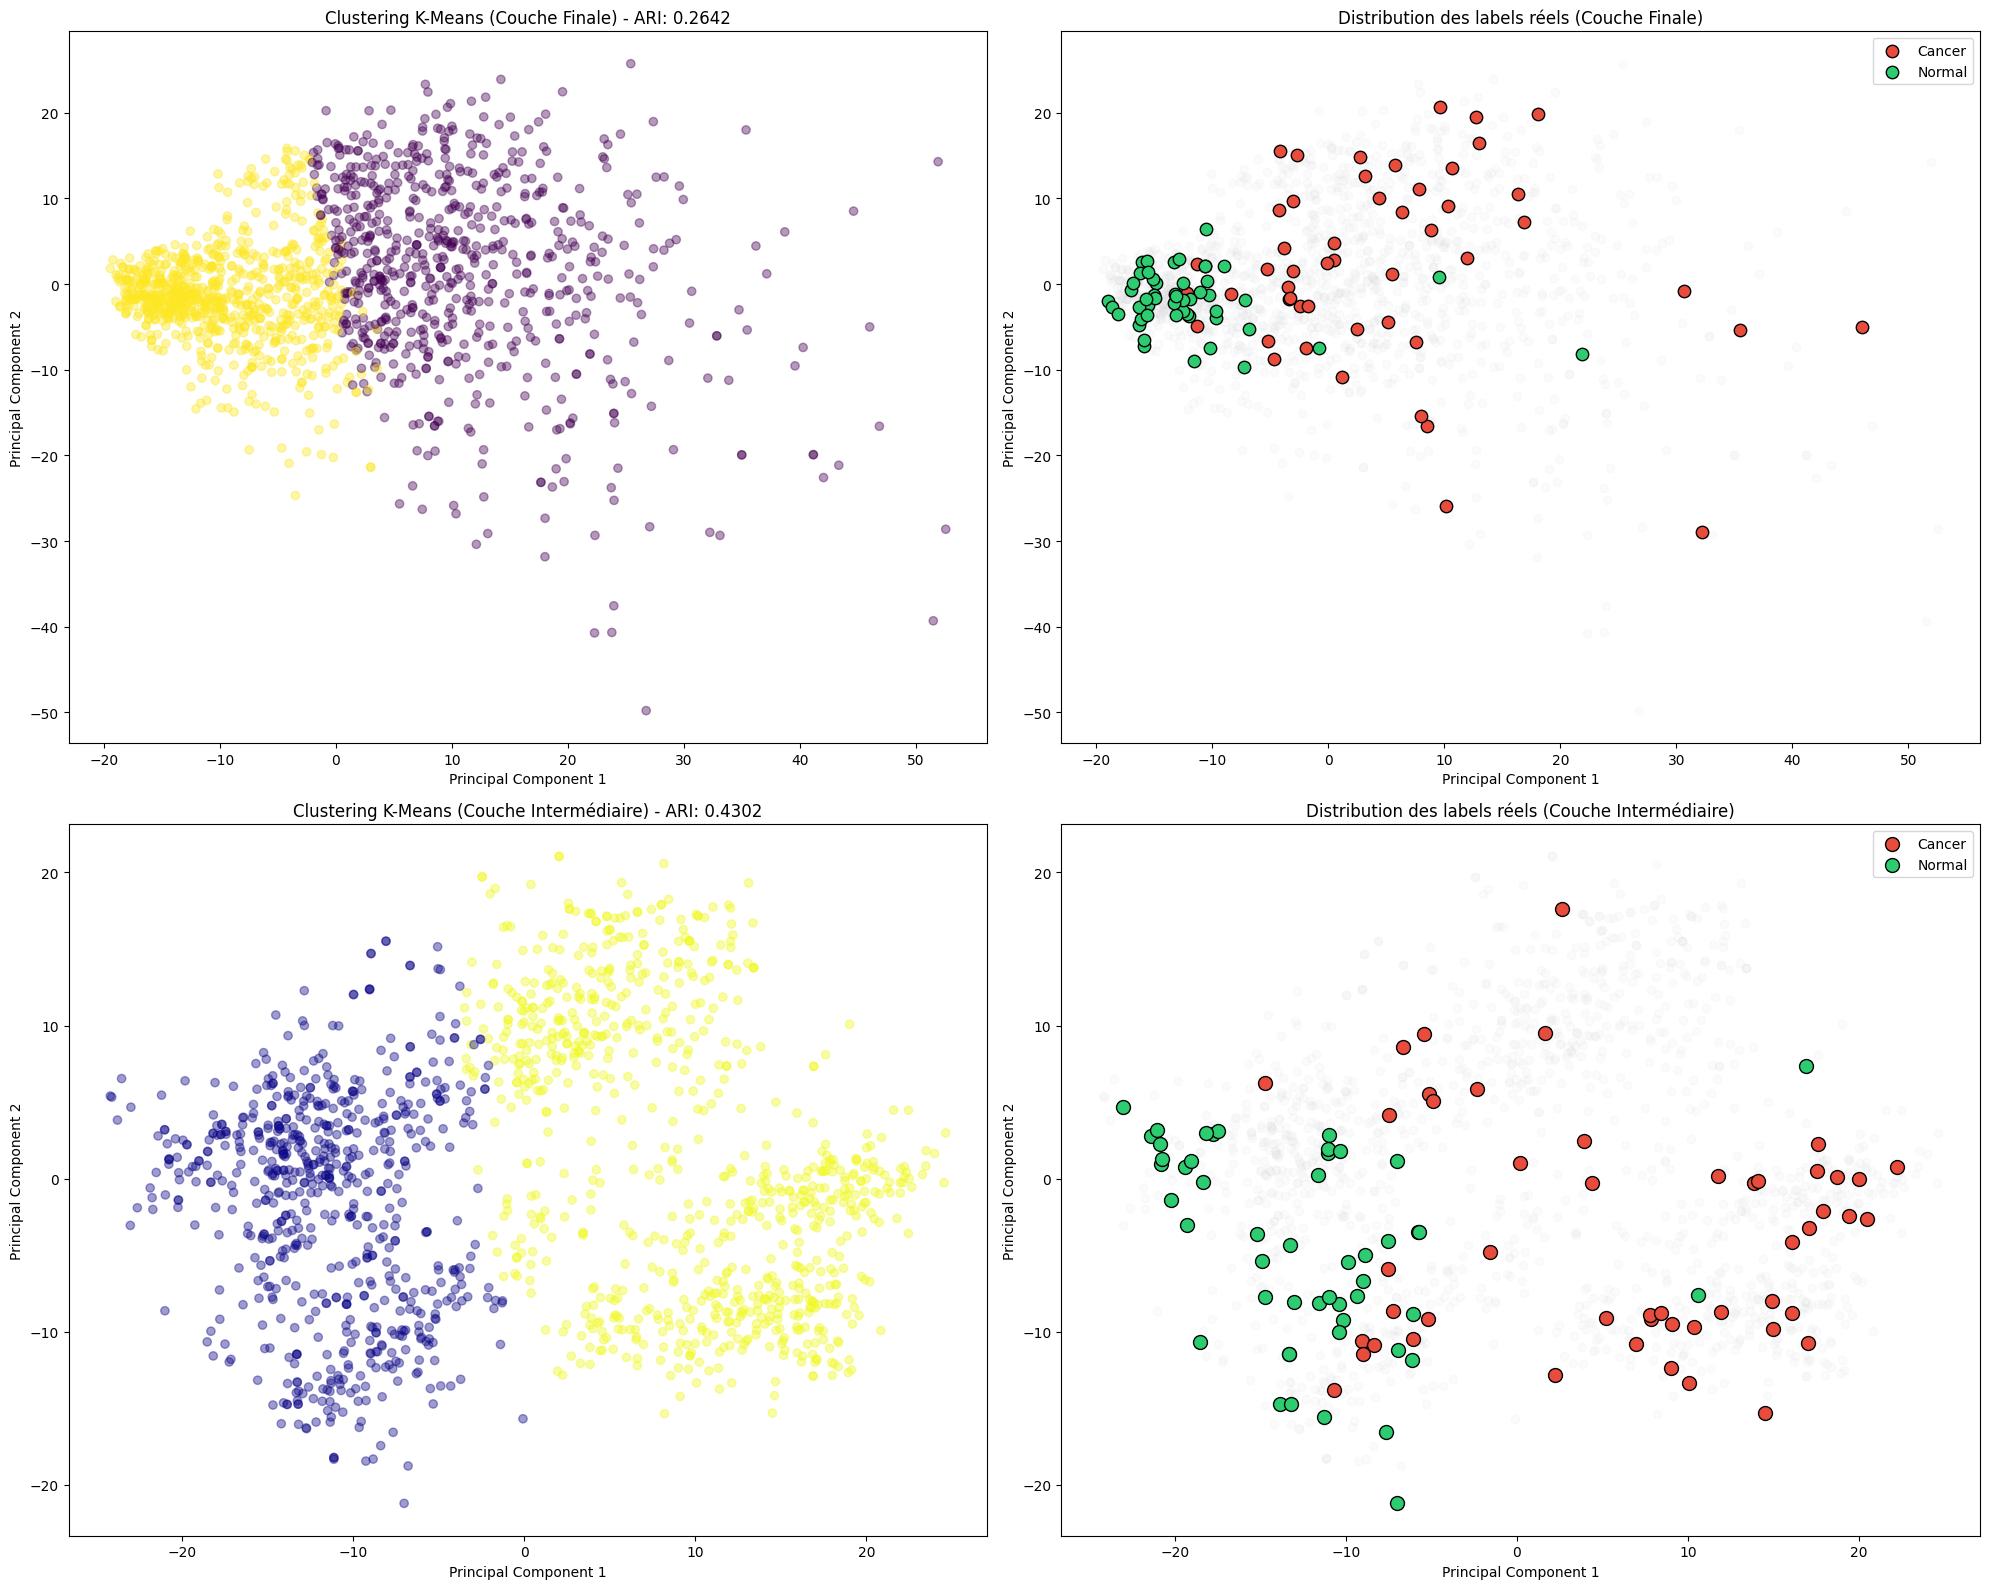

In [75]:
# Configuration des couleurs et styles
color_dict = {'cancer': '#e74c3c', 'normal': '#2ecc71', 'Unknown': '#dcdde1'}

# Création de la figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- LIGNE 1 : COUCHE FINALE ---
# IA
axes[0, 0].scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=clus_final, cmap='viridis', alpha=0.4)
axes[0, 0].set_title(f"Clustering K-Means (Couche Finale) - ARI: {ari_final:.4f}")

# Labels réels
axes[0, 1].scatter(X_pca_final[~mask_labeled, 0], X_pca_final[~mask_labeled, 1], c='#dcdde1', alpha=0.1)
for lbl in ['cancer', 'normal']:
    m = df_features['label'] == lbl
    axes[0, 1].scatter(X_pca_final[m, 0], X_pca_final[m, 1], c=color_dict[lbl], s=80, edgecolors='black', label=lbl.capitalize())
axes[0, 1].set_title("Distribution des labels réels (Couche Finale)")

# --- LIGNE 2 : COUCHE INTERMÉDIAIRE ---
# IA
axes[1, 0].scatter(X_pca_inter[:, 0], X_pca_inter[:, 1], c=clus_inter, cmap='plasma', alpha=0.4)
axes[1, 0].set_title(f"Clustering K-Means (Couche Intermédiaire) - ARI: {ari_inter:.4f}")

# Labels réels
axes[1, 1].scatter(X_pca_inter[~mask_labeled, 0], X_pca_inter[~mask_labeled, 1], c='#dcdde1', alpha=0.1)
for lbl in ['cancer', 'normal']:
    m = df_features['label'] == lbl
    axes[1, 1].scatter(X_pca_inter[m, 0], X_pca_inter[m, 1], c=color_dict[lbl], s=100, edgecolors='black', label=lbl.capitalize())
axes[1, 1].set_title("Distribution des labels réels (Couche Intermédiaire)")

# Mise en page
for ax in axes.flat:
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
axes[0, 1].legend()
axes[1, 1].legend()

plt.tight_layout()
plt.show()

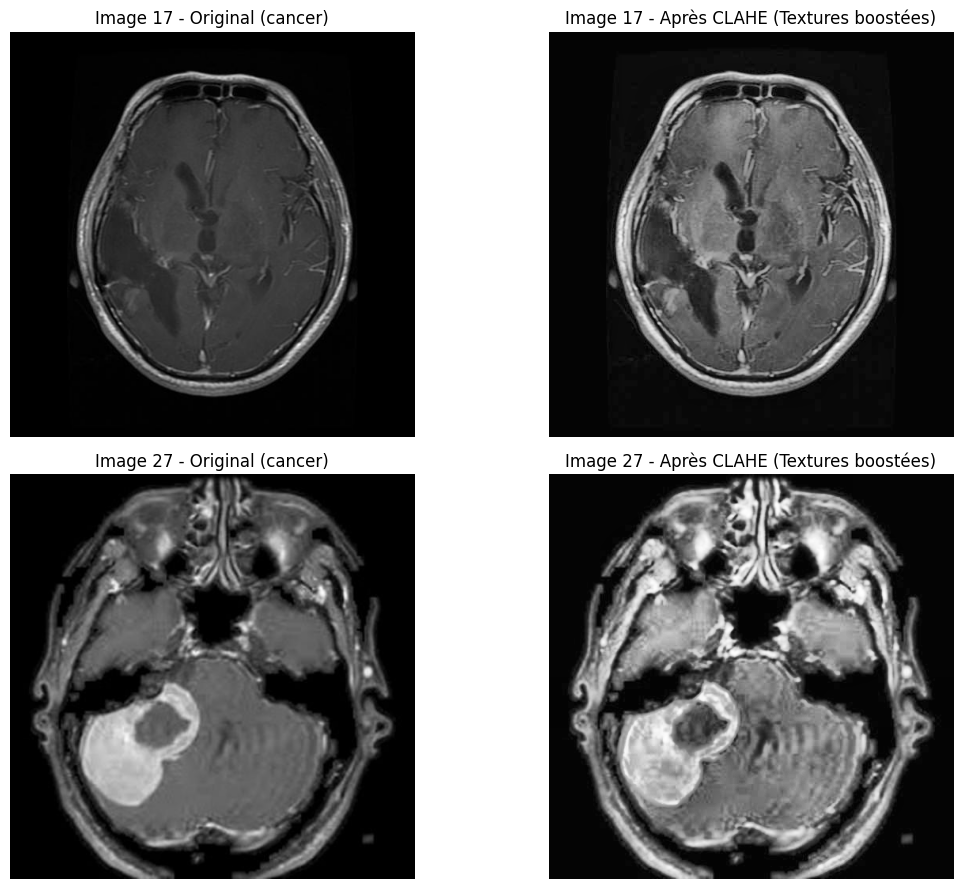

In [77]:
# --- CELLULE DE VALIDATION VISUELLE DU CLAHE ---

# 1. On définit les indices à tester (un cancer et un normal pour comparer)
indices_a_tester = [17, 27] 
clahe_transformer = ApplyCLAHE(clip_limit=3.0)

# 2. Création de la figure (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for i, idx in enumerate(indices_a_tester):
    # Chargement
    path = df_features.iloc[idx]['path']
    label = df_features.iloc[idx]['label']
    img_orig = Image.open(path).convert('RGB')
    
    # Transformation
    img_boosted = clahe_transformer(img_orig)
    
    # Affichage Original
    axes[i, 0].imshow(img_orig)
    axes[i, 0].set_title(f"Image {idx} - Original ({label})")
    axes[i, 0].axis('off')
    
    # Affichage CLAHE
    axes[i, 1].imshow(img_boosted)
    axes[i, 1].set_title(f"Image {idx} - Après CLAHE (Textures boostées)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()